In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

print("✅ Bibliotecas carregadas!")

✅ Bibliotecas carregadas!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/agroguard/dataset_agroguard.csv")

print(f"✅ Dataset carregado: {len(df)} registros")
print(f"Colunas: {list(df.columns)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset carregado: 1827 registros
Colunas: ['temp_max', 'precipitacao', 'vento_max', 'umidade_max', 'mes', 'dia_do_ano', 'dias_sem_chuva', 'risco']


In [3]:
# Target: o que o modelo vai prever
y = df['risco']

# Features: apenas dados climáticos
X = df.drop(columns=['risco'])

print(f"✅ Features: {list(X.columns)}")
print(f"✅ Shape de X: {X.shape}")
print(f"✅ Shape de y: {y.shape}")

✅ Features: ['temp_max', 'precipitacao', 'vento_max', 'umidade_max', 'mes', 'dia_do_ano', 'dias_sem_chuva']
✅ Shape de X: (1827, 7)
✅ Shape de y: (1827,)


In [4]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,      # 20% para teste
    random_state=42,    # garante que a divisão seja sempre igual
    stratify=y          # mantém a proporção de cada classe
)

print(f"✅ Treino: {len(X_treino)} dias")
print(f"✅ Teste:  {len(X_teste)} dias")
print(f"\nDistribuição no treino:")
print(y_treino.value_counts().sort_index())

✅ Treino: 1461 dias
✅ Teste:  366 dias

Distribuição no treino:
risco
0    658
1    500
2    303
Name: count, dtype: int64


In [5]:
print("🌲 Treinando o Random Forest...")

modelo = RandomForestClassifier(
    n_estimators=200,     # 200 árvores de decisão
    max_depth=15,         # profundidade máxima de cada árvore
    min_samples_leaf=2,   # mínimo de amostras por folha
    random_state=42,
    n_jobs=-1             # usa todos os núcleos disponíveis
)

modelo.fit(X_treino, y_treino)

print("✅ Modelo treinado!")

🌲 Treinando o Random Forest...
✅ Modelo treinado!


In [6]:
y_pred = modelo.predict(X_teste)

acuracia = accuracy_score(y_teste, y_pred)
print(f"🎯 Acurácia: {acuracia:.2%}\n")

print("📊 Relatório detalhado:")
print(classification_report(
    y_teste, y_pred,
    target_names=['Baixo', 'Médio', 'Alto']
))

🎯 Acurácia: 71.04%

📊 Relatório detalhado:
              precision    recall  f1-score   support

       Baixo       0.77      0.91      0.83       165
       Médio       0.60      0.53      0.56       125
        Alto       0.73      0.58      0.65        76

    accuracy                           0.71       366
   macro avg       0.70      0.67      0.68       366
weighted avg       0.70      0.71      0.70       366



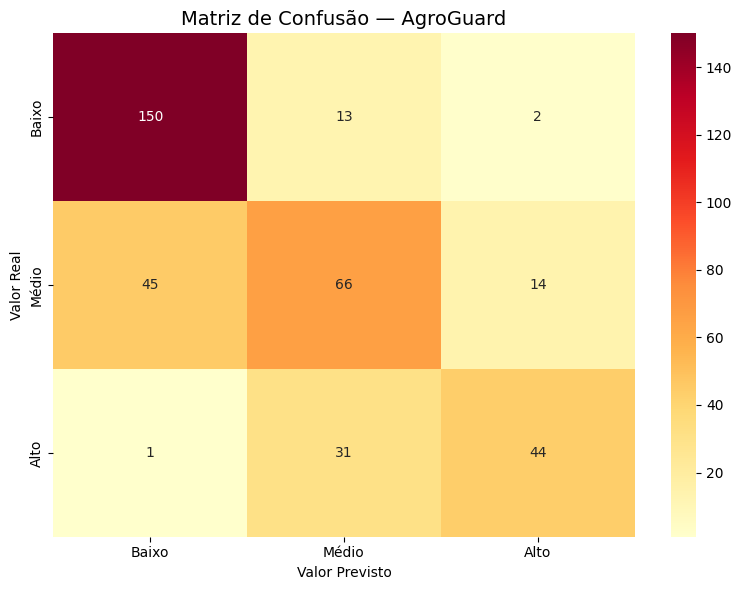

💾 Imagem salva no Drive!


In [7]:
# A matriz de confusão mostra onde o modelo acerta e onde erra
cm = confusion_matrix(y_teste, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    xticklabels=['Baixo', 'Médio', 'Alto'],
    yticklabels=['Baixo', 'Médio', 'Alto']
)
plt.title('Matriz de Confusão — AgroGuard', fontsize=14)
plt.ylabel('Valor Real')
plt.xlabel('Valor Previsto')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/agroguard/matriz_confusao.png", dpi=150)
plt.show()
print("💾 Imagem salva no Drive!")

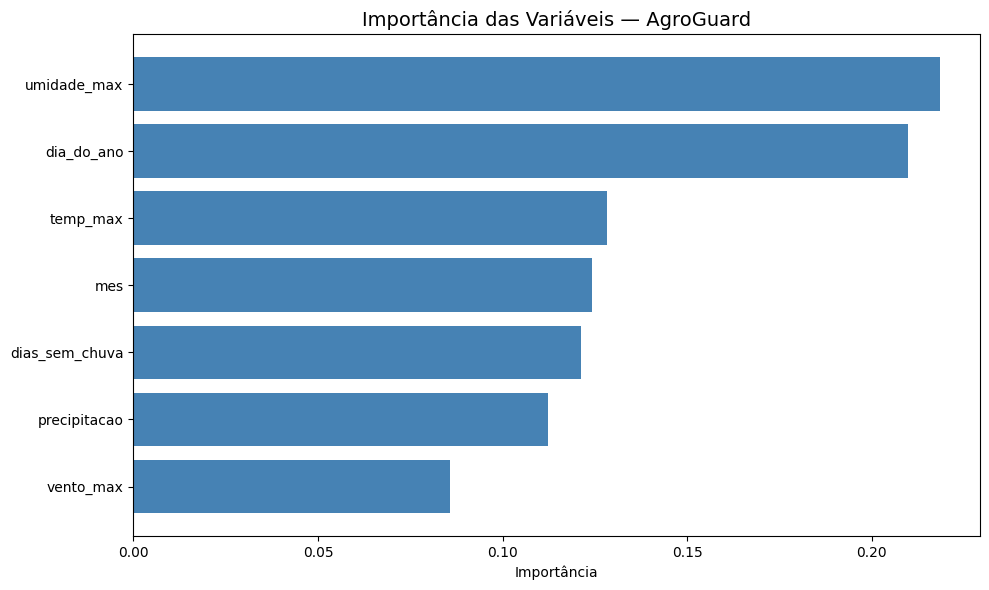


🔍 Top 3 variáveis mais importantes:
  umidade_max: 21.84%
  dia_do_ano: 20.97%
  temp_max: 12.83%


In [8]:
# Quais variáveis o modelo considerou mais importantes?
importancias = pd.DataFrame({
    'feature': X.columns,
    'importancia': modelo.feature_importances_
}).sort_values('importancia', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importancias['feature'], importancias['importancia'], color='steelblue')
plt.title('Importância das Variáveis — AgroGuard', fontsize=14)
plt.xlabel('Importância')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/agroguard/importancia_features.png", dpi=150)
plt.show()

print("\n🔍 Top 3 variáveis mais importantes:")
top3 = importancias.sort_values('importancia', ascending=False).head(3)
for _, row in top3.iterrows():
    print(f"  {row['feature']}: {row['importancia']:.2%}")

In [9]:
from sklearn.model_selection import GridSearchCV

print("🔍 Buscando melhores hiperparâmetros...")
print("(isso pode levar alguns minutos)\n")

# Grade de parâmetros para testar
parametros = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf,
    parametros,
    cv=5,              # validação cruzada em 5 partes
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_treino, y_treino)

print(f"\n✅ Melhores parâmetros encontrados:")
print(grid_search.best_params_)
print(f"\n🎯 Melhor acurácia no treino: {grid_search.best_score_:.2%}")

🔍 Buscando melhores hiperparâmetros...
(isso pode levar alguns minutos)

Fitting 5 folds for each of 72 candidates, totalling 360 fits

✅ Melhores parâmetros encontrados:
{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 300}

🎯 Melhor acurácia no treino: 76.39%


In [10]:
from xgboost import XGBClassifier

print("🚀 Treinando XGBoost...")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)

xgb.fit(X_treino, y_treino)

y_pred_xgb = xgb.predict(X_teste)
acuracia_xgb = accuracy_score(y_teste, y_pred_xgb)

print(f"🎯 Acurácia XGBoost: {acuracia_xgb:.2%}\n")
print("📊 Relatório detalhado:")
print(classification_report(
    y_teste, y_pred_xgb,
    target_names=['Baixo', 'Médio', 'Alto']
))

🚀 Treinando XGBoost...
🎯 Acurácia XGBoost: 70.77%

📊 Relatório detalhado:
              precision    recall  f1-score   support

       Baixo       0.78      0.90      0.83       165
       Médio       0.58      0.54      0.56       125
        Alto       0.73      0.57      0.64        76

    accuracy                           0.71       366
   macro avg       0.70      0.67      0.68       366
weighted avg       0.70      0.71      0.70       366



In [11]:
# Avalia o modelo otimizado do GridSearch
melhor_rf = grid_search.best_estimator_
y_pred_rf_otimizado = melhor_rf.predict(X_teste)
acuracia_rf_otimizado = accuracy_score(y_teste, y_pred_rf_otimizado)

# Acurácia do modelo original
acuracia_original = accuracy_score(y_teste, modelo.predict(X_teste))

print("📊 Comparação dos modelos:")
print(f"  Random Forest original:  {acuracia_original:.2%}")
print(f"  Random Forest otimizado: {acuracia_rf_otimizado:.2%}")
print(f"  XGBoost:                 {acuracia_xgb:.2%}")

# Escolhe o melhor
melhor_acuracia = max(acuracia_original, acuracia_rf_otimizado, acuracia_xgb)

if melhor_acuracia == acuracia_xgb:
    modelo_final = xgb
    nome_modelo = "XGBoost"
elif melhor_acuracia == acuracia_rf_otimizado:
    modelo_final = melhor_rf
    nome_modelo = "Random Forest Otimizado"
else:
    modelo_final = modelo
    nome_modelo = "Random Forest Original"

print(f"\n🏆 Melhor modelo: {nome_modelo} ({melhor_acuracia:.2%})")

📊 Comparação dos modelos:
  Random Forest original:  71.04%
  Random Forest otimizado: 70.77%
  XGBoost:                 70.77%

🏆 Melhor modelo: Random Forest Original (71.04%)


In [12]:
os.makedirs("/content/drive/MyDrive/agroguard", exist_ok=True)

joblib.dump(modelo_final, "/content/drive/MyDrive/agroguard/modelo_agroguard.pkl")
joblib.dump(list(X.columns), "/content/drive/MyDrive/agroguard/features.pkl")

print(f"💾 Modelo salvo: {nome_modelo}")
print(f"🎯 Acurácia final: {melhor_acuracia:.2%}")
print("\n✅ Etapa 3 concluída!")

💾 Modelo salvo: Random Forest Original
🎯 Acurácia final: 71.04%

✅ Etapa 3 concluída!


In [13]:
%%writefile dashboard.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import folium
from streamlit_folium import st_folium
import plotly.express as px
import plotly.graph_objects as go
from datetime import date

# ─── Configuração da página ───────────────────────────────────────────────────
st.set_page_config(
    page_title="AgroGuard",
    page_icon="🔥",
    layout="wide"
)

# ─── Estilo visual ────────────────────────────────────────────────────────────
st.markdown("""
    <style>
        .titulo-principal {
            font-size: 2.5rem;
            font-weight: 800;
            color: #D62828;
        }
        .subtitulo {
            font-size: 1.1rem;
            color: #666;
            margin-bottom: 2rem;
        }
        .card-baixo  { background: #d4edda; padding: 1.5rem; border-radius: 12px; text-align: center; }
        .card-medio  { background: #fff3cd; padding: 1.5rem; border-radius: 12px; text-align: center; }
        .card-alto   { background: #f8d7da; padding: 1.5rem; border-radius: 12px; text-align: center; }
        .card-titulo { font-size: 1.1rem; font-weight: 600; margin-bottom: 0.5rem; }
        .card-valor  { font-size: 2.5rem; font-weight: 800; }
    </style>
""", unsafe_allow_html=True)

# ─── Cabeçalho ────────────────────────────────────────────────────────────────
st.markdown('<div class="titulo-principal">🔥 AgroGuard</div>', unsafe_allow_html=True)
st.markdown('<div class="subtitulo">Plataforma inteligente de previsão de risco de queimadas no Cerrado brasileiro</div>', unsafe_allow_html=True)
st.markdown("---")

# ─── Carregamento do modelo e dados ───────────────────────────────────────────
@st.cache_resource
def carregar_modelo():
    modelo   = joblib.load("modelo_agroguard.pkl")
    features = joblib.load("features.pkl")
    return modelo, features

@st.cache_data
def carregar_dados():
    df_focos  = pd.read_csv("focos_cerrado_2020_2024.csv")
    df_modelo = pd.read_csv("dataset_agroguard.csv")
    return df_focos, df_modelo

modelo, features = carregar_modelo()
df_focos, df_modelo = carregar_dados()

# ─── Abas do dashboard ────────────────────────────────────────────────────────
aba1, aba2, aba3 = st.tabs([
    "🎯 Simulador de Risco",
    "🗺️ Mapa de Focos",
    "📈 Análise Temporal"
])

# ══════════════════════════════════════════════════════════════════════════════
# ABA 1 — SIMULADOR DE RISCO
# ══════════════════════════════════════════════════════════════════════════════
with aba1:
    st.subheader("Simulador de Risco Climático")
    st.write("Informe as condições climáticas do dia para prever o nível de risco de queimadas.")

    col1, col2 = st.columns(2)

    with col1:
        temp_max       = st.slider("🌡️ Temperatura máxima (°C)", 15.0, 45.0, 32.0, 0.5)
        precipitacao   = st.slider("🌧️ Precipitação (mm)", 0.0, 100.0, 0.0, 0.5)
        vento_max      = st.slider("💨 Velocidade do vento (km/h)", 0.0, 60.0, 15.0, 0.5)

    with col2:
        umidade_max    = st.slider("💧 Umidade máxima (%)", 10.0, 100.0, 40.0, 1.0)
        dias_sem_chuva = st.slider("☀️ Dias consecutivos sem chuva", 0, 60, 10, 1)
        data_ref       = st.date_input("📅 Data de referência", date.today())

    mes        = data_ref.month
    dia_do_ano = data_ref.timetuple().tm_yday

    entrada = pd.DataFrame([{
        "temp_max"       : temp_max,
        "precipitacao"   : precipitacao,
        "vento_max"      : vento_max,
        "umidade_max"    : umidade_max,
        "dias_sem_chuva" : dias_sem_chuva,
        "mes"            : mes,
        "dia_do_ano"     : dia_do_ano
    }])[features]

    if st.button("🔍 Prever Risco", use_container_width=True):
        predicao      = modelo.predict(entrada)[0]
        probabilidade = modelo.predict_proba(entrada)[0]

        st.markdown("---")
        st.subheader("Resultado da Previsão")

        if predicao == 0:
            st.markdown("""
                <div class="card-baixo">
                    <div class="card-titulo">Nível de Risco</div>
                    <div class="card-valor">🟢 BAIXO</div>
                </div>
            """, unsafe_allow_html=True)
        elif predicao == 1:
            st.markdown("""
                <div class="card-medio">
                    <div class="card-titulo">Nível de Risco</div>
                    <div class="card-valor">🟡 MÉDIO</div>
                </div>
            """, unsafe_allow_html=True)
        else:
            st.markdown("""
                <div class="card-alto">
                    <div class="card-titulo">Nível de Risco</div>
                    <div class="card-valor">🔴 ALTO</div>
                </div>
            """, unsafe_allow_html=True)

        st.markdown("<br>", unsafe_allow_html=True)

        fig_prob = go.Figure(go.Bar(
            x=['Baixo', 'Médio', 'Alto'],
            y=[p * 100 for p in probabilidade],
            marker_color=['#28a745', '#ffc107', '#dc3545'],
            text=[f"{p*100:.1f}%" for p in probabilidade],
            textposition='outside'
        ))
        fig_prob.update_layout(
            title="Probabilidade por nível de risco",
            yaxis_title="Probabilidade (%)",
            yaxis_range=[0, 110],
            height=350
        )
        st.plotly_chart(fig_prob, use_container_width=True)

        st.markdown("### 💡 Recomendações")
        if predicao == 0:
            st.success("✅ Condições favoráveis. Mantenha o monitoramento de rotina.")
        elif predicao == 1:
            st.warning("⚠️ Atenção recomendada. Evite queimas controladas e mantenha equipes em alerta.")
        else:
            st.error("🚨 Risco crítico! Acione brigadistas, suspenda qualquer atividade com fogo e notifique autoridades.")

# ══════════════════════════════════════════════════════════════════════════════
# ABA 2 — MAPA DE FOCOS
# ══════════════════════════════════════════════════════════════════════════════
with aba2:
    st.subheader("Mapa de Focos de Calor — Cerrado Brasileiro")

    col_filtro1, col_filtro2 = st.columns(2)
    with col_filtro1:
        ano_selecionado = st.selectbox("Selecione o ano", [2020, 2021, 2022, 2023, 2024])
    with col_filtro2:
        mes_selecionado = st.selectbox("Selecione o mês", range(1, 13),
                                        format_func=lambda x: [
                                            "Janeiro","Fevereiro","Março","Abril",
                                            "Maio","Junho","Julho","Agosto",
                                            "Setembro","Outubro","Novembro","Dezembro"
                                        ][x-1])

    df_focos['acq_date'] = pd.to_datetime(df_focos['acq_date'])
    df_filtrado = df_focos[
        (df_focos['acq_date'].dt.year  == ano_selecionado) &
        (df_focos['acq_date'].dt.month == mes_selecionado)
    ]

    st.info(f"📍 {len(df_filtrado):,} focos detectados em {mes_selecionado:02d}/{ano_selecionado}")

    amostra = df_filtrado.sample(min(500, len(df_filtrado)), random_state=42) if len(df_filtrado) > 0 else df_filtrado

    mapa = folium.Map(location=[-15.0, -48.0], zoom_start=5, tiles="CartoDB dark_matter")

    for _, row in amostra.iterrows():
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=3,
            color='#FF4500',
            fill=True,
            fill_color='#FF6347',
            fill_opacity=0.7,
            popup=f"Data: {row['acq_date'].date()}<br>FRP: {row['frp']:.1f} MW"
        ).add_to(mapa)

    st_folium(mapa, width=None, height=500)

# ══════════════════════════════════════════════════════════════════════════════
# ABA 3 — ANÁLISE TEMPORAL
# ══════════════════════════════════════════════════════════════════════════════
with aba3:
    st.subheader("Evolução do Risco ao Longo do Tempo")

    df_modelo['risco_nome'] = df_modelo['risco'].map({
        0: 'Baixo', 1: 'Médio', 2: 'Alto'
    })

    risco_mes = df_modelo.groupby(['mes', 'risco_nome']).size().reset_index(name='dias')
    risco_mes['mes_nome'] = risco_mes['mes'].map({
        1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
        7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'
    })

    fig_mensal = px.bar(
        risco_mes,
        x='mes_nome',
        y='dias',
        color='risco_nome',
        color_discrete_map={'Baixo':'#28a745', 'Médio':'#ffc107', 'Alto':'#dc3545'},
        title='Distribuição Mensal do Risco de Queimadas (2020–2024)',
        labels={'dias': 'Número de dias', 'mes_nome': 'Mês', 'risco_nome': 'Risco'},
        category_orders={'mes_nome': ['Jan','Fev','Mar','Abr','Mai','Jun',
                                       'Jul','Ago','Set','Out','Nov','Dez']}
    )
    st.plotly_chart(fig_mensal, use_container_width=True)

    fig_box = px.box(
        df_modelo,
        x='risco_nome',
        y='temp_max',
        color='risco_nome',
        color_discrete_map={'Baixo':'#28a745', 'Médio':'#ffc107', 'Alto':'#dc3545'},
        title='Temperatura Máxima por Nível de Risco',
        labels={'temp_max': 'Temperatura Máxima (°C)', 'risco_nome': 'Nível de Risco'},
        category_orders={'risco_nome': ['Baixo', 'Médio', 'Alto']}
    )
    st.plotly_chart(fig_box, use_container_width=True)

# ─── Rodapé ───────────────────────────────────────────────────────────────────
st.markdown("---")
st.markdown(
    "<center><small>AgroGuard © 2026 — Desenvolvido com dados da NASA FIRMS e Open-Meteo</small></center>",
    unsafe_allow_html=True
)

Writing dashboard.py


In [14]:
from google.colab import drive
drive.mount('/content/drive')

!pip install streamlit streamlit-folium folium plotly pyngrok -q

import shutil
shutil.copy("/content/drive/MyDrive/agroguard/modelo_agroguard.pkl", "modelo_agroguard.pkl")
shutil.copy("/content/drive/MyDrive/agroguard/features.pkl", "features.pkl")
shutil.copy("/content/drive/MyDrive/agroguard/dataset_agroguard.csv", "dataset_agroguard.csv")
shutil.copy("/content/drive/MyDrive/agroguard/focos_cerrado_2020_2024.csv", "focos_cerrado_2020_2024.csv")

print("✅ Arquivos prontos!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.5/530.5 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 103.1 MB/s eta 0:00:00
✅ Arquivos prontos!


In [ ]:
import subprocess, time, threading

# Sobe o Streamlit em background
subprocess.Popen(["streamlit", "run", "dashboard.py",
                  "--server.port=8501", "--server.headless=true"])
time.sleep(5)

# Instala e sobe o localtunnel
!npm install -g localtunnel -q

# Pega o IP externo do Colab
import urllib.request
ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip()
print(f"🔑 Quando abrir o link, cole esse IP na tela de acesso: {ip}")

# Sobe o túnel
!lt --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 5s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸🔑 Quando abrir o link, cole esse IP na tela de acesso: 34.181.210.191
your url is: https://lucky-candles-grab.loca.lt
